In [ ]:
# pip install git+https://github.com/huggingface/diffusers.git

In [1]:
import torch
from diffusers import Flux2KleinPipeline, AutoencoderKLFlux2

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
import torch
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    subfolder="vae",
    torch_dtype=torch.bfloat16
).to("cuda")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/821 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Some weights of the model checkpoint at black-forest-labs/FLUX.2-klein-4B were not used when initializing AutoencoderKL: 
 ['bn.num_batches_tracked, bn.running_var, bn.running_mean']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import numpy as np
from PIL import Image

img = Image.open("/content/drive/MyDrive/hanyang/eachneuron.jpg").convert("RGB")
img = img.resize((512, 512))

x = np.array(img).astype(np.float32) / 255.0        # [0,1], shape (H,W,3)
x = torch.from_numpy(x).permute(2, 0, 1)            # -> (3,H,W)
x = x * 2.0 - 1.0                                 # [0,1] -> [-1,1]
x = x[None, :, :, :]                               # -> (1,3,H,W)
x = x.to("cuda", dtype=torch.bfloat16)

with torch.no_grad():
    z = vae.encode(x).latent_dist.sample()

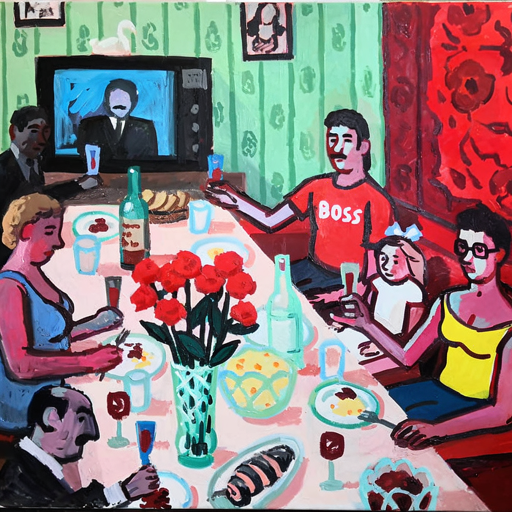

In [6]:
with torch.no_grad():
    fin = vae.decode(z).sample          # (1,3,H,W), range ~[-1,1], sur cuda

img_t = fin[0]                          # enlève le batch -> (3,H,W)
img_t = (img_t / 2 + 0.5).clamp(0, 1)   # [-1,1] -> [0,1]
img_t = img_t.permute(1, 2, 0)          # (3,H,W) -> (H,W,3)
img_np = (img_t.float().cpu().numpy() * 255).round().astype(np.uint8)

Image.fromarray(img_np) 